In [1]:
# import fetch_california_housing dataset from sklearn
# check and handle the inconsistencies
#    -in houseAge fill null values with mean
#    -in population fill null values with median
# encode the catergorical columns
# seperate x and y
# train test and split
# scale the features


In [3]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [7]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [22]:
num_cols = df.select_dtypes(include=['float64']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [25]:
for num in num_cols:
    
    Q1 = df[num].quantile(0.25)
    Q3 = df[num].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[num] < lower) | (df[num] > upper)]
    
    print(num, "Outliers:", len(outliers))

MedInc Outliers: 112
houseAge Outliers: 0
AveRooms Outliers: 80
AveBedrms Outliers: 127
population Outliers: 316
AveOccup Outliers: 115
Latitude Outliers: 0
Longitude Outliers: 0
Price Outliers: 142


In [30]:
df.columns

Index(['MedInc', 'houseAge', 'AveRooms', 'AveBedrms', 'population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

In [35]:
# feature engineering

# population per household
df["population_per_household"] = df["population"] / df["houseAge"]
# bedroom ratio
df["BedroomRatio"] = df["AveBedrms"] / df["AveRooms"]

# population density
df["PopulationDensity"] = df["population"] / df["AveRooms"]
df[["population_per_household","BedroomRatio","PopulationDensity"]].head()


,population_per_household,BedroomRatio,PopulationDensity
3,10.730769,0.184458,95.919937
4,10.865385,0.172096,89.941610
5,7.942308,0.231774,86.734494
6,21.038462,0.192899,221.820907
7,22.250000,0.221327,241.165915


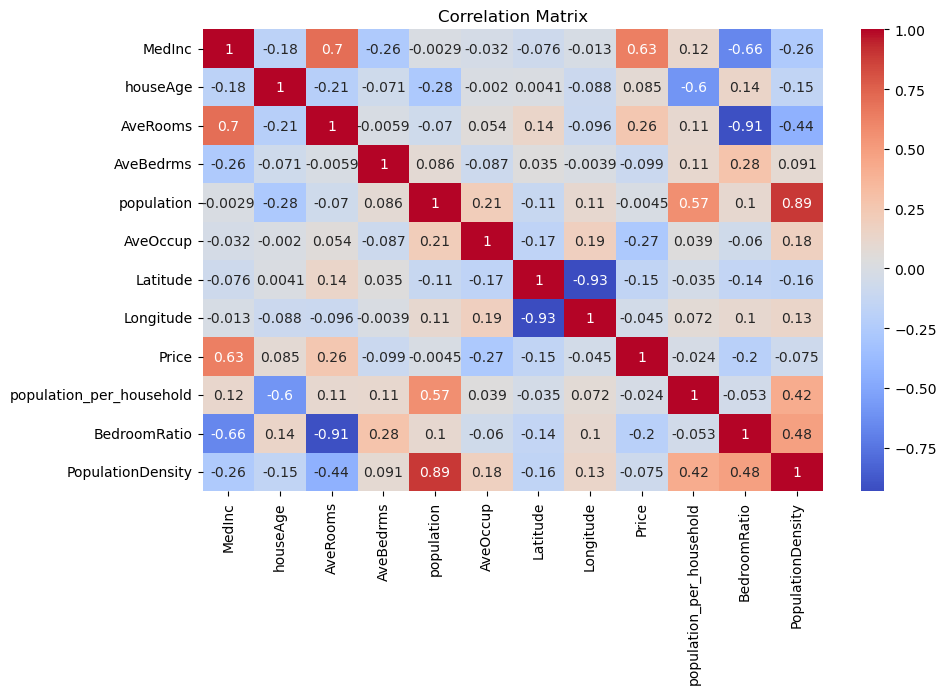

In [36]:
# check for correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# create a heatmap to check the correlation for

In [40]:
# scale features and targets
X=df.drop('Price',axis=1)
y=df['Price'] 

In [43]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12985, 11)
(3247, 11)
(12985,)
(3247,)


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
print(X_train[:5])
print(y_train[:5])

[[ 1.33760253 -1.17709041  1.17150141 -0.30798256 -0.55534437  1.03122625
  -0.70201311  0.3429665  -0.00261682 -1.0234709  -0.76444814]
 [-0.55264587  1.85227076 -0.63368385  2.22098925 -1.50556436 -1.69783139
   1.34585728 -0.93023408 -0.76673321  1.06522003 -1.24802464]
 [-0.74711042  0.86977525 -0.7961565  -0.60791391  0.1387431   0.31222558
  -0.74399678  0.74898716 -0.38333542  0.40547811  0.35734909]
 [-0.1790399   0.29665286  0.52768407 -0.14193218 -0.20909117 -0.29290313
  -1.35042765  1.34047405 -0.37532589 -0.60655908 -0.39802182]
 [-0.17158728  1.85227076 -0.52133743 -0.70986483 -0.46996687 -0.45578538
   1.36918154 -1.62197298 -0.59355512  0.08899654 -0.3221595 ]]
20361    2.356
12552    1.250
6803     2.284
15040    1.381
19342    1.833
Name: Price, dtype: float64


In [54]:
# linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.3095520616228531
R2 Score: 0.6388385674863681


In [55]:
# Ridge regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

MSE: 0.30955155972994586
R2 Score: 0.638839153056241


In [57]:
# Loss regression
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

MSE: 0.4455067309157257
R2 Score: 0.48021716189368147
